In [1]:
#tugas1
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Basic SQL Operations").getOrCreate()

data = [
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
]

columns = ['Name', 'Age', 'Gender', 'Salary', 'DeptId']

df = spark.createDataFrame(data, schema=columns)
df.show()
df.createOrReplaceTempView('employees')

#Menampilkan semua data
print("=== SELECT * FROM employees ===")
spark.sql('SELECT * FROM employees').show()

#Menampilkan karyawan dengan gaji di atas 3000
print("=== SELECT Name, Age FROM employees WHERE Salary > 3000 ===")
spark.sql('SELECT Name, Age FROM employees WHERE Salary > 3000').show()

#Menghitung rata-rata gaji
print("=== SELECT AVG(Salary) FROM employees ===")
spark.sql('SELECT AVG(Salary) AS Average_Salary FROM employees').show()

25/10/25 23:32:54 WARN Utils: Your hostname, apfia-VirtualBox resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
25/10/25 23:32:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/25 23:33:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

+-----+---+------+------+------+
| Name|Age|Gender|Salary|DeptId|
+-----+---+------+------+------+
|James| 34|     M|  3000|     1|
| Anna| 28|     F|  4100|     2|
|  Lee| 23|     M|  2700|     1|
+-----+---+------+------+------+

=== SELECT * FROM employees ===


+-----+---+------+------+------+
| Name|Age|Gender|Salary|DeptId|
+-----+---+------+------+------+
|James| 34|     M|  3000|     1|
| Anna| 28|     F|  4100|     2|
|  Lee| 23|     M|  2700|     1|
+-----+---+------+------+------+

=== SELECT Name, Age FROM employees WHERE Salary > 3000 ===


+----+---+
|Name|Age|
+----+---+
|Anna| 28|
+----+---+

=== SELECT AVG(Salary) FROM employees ===


+------------------+
|    Average_Salary|
+------------------+
|3266.6666666666665|
+------------------+



In [2]:
#tugas2
spark.sql("""
SELECT Gender,
       Age,
       SUM(Salary) AS TotalSalary
FROM employees
GROUP BY Gender, Age
ORDER BY Age
""").show()

#2a
spark.sql("""
SELECT DeptId,
       AVG(Salary) AS AvgSalary
FROM employees
GROUP BY DeptId
ORDER BY DeptId
""").show()

#2b
spark.sql("""
SELECT Name, Gender, Salary
FROM (
  SELECT Name, Gender, Salary,
         AVG(Salary) OVER (PARTITION BY Gender) AS AvgByGender
  FROM employees
) t
WHERE Salary > AvgByGender
ORDER BY Gender, Salary DESC
""").show()

#2c
spark.sql("""
SELECT DeptId, Name, Salary,
       DENSE_RANK() OVER (PARTITION BY DeptId ORDER BY Salary DESC) AS RankInDept
FROM employees
ORDER BY DeptId, RankInDept
""").show()

+------+---+-----------+
|Gender|Age|TotalSalary|
+------+---+-----------+
|     M| 23|       2700|
|     F| 28|       4100|
|     M| 34|       3000|
+------+---+-----------+

+------+---------+
|DeptId|AvgSalary|
+------+---------+
|     1|   2850.0|
|     2|   4100.0|
+------+---------+

+-----+------+------+
| Name|Gender|Salary|
+-----+------+------+
|James|     M|  3000|
+-----+------+------+

+------+-----+------+----------+
|DeptId| Name|Salary|RankInDept|
+------+-----+------+----------+
|     1|James|  3000|         1|
|     1|  Lee|  2700|         2|
|     2| Anna|  4100|         1|
+------+-----+------+----------+



In [3]:
#tugas3
spark.sql("""
WITH ranked AS (
  SELECT Name, Age, Salary,
         ROW_NUMBER() OVER (PARTITION BY Age ORDER BY Salary DESC) AS rk
  FROM employees
)
SELECT Name, Age, Salary, rk AS rank
FROM ranked
WHERE rk <= 3
ORDER BY Age, rk
""").show()

[Stage 26:>                                                         (0 + 1) / 1]

+-----+---+------+----+
| Name|Age|Salary|rank|
+-----+---+------+----+
|  Lee| 23|  2700|   1|
| Anna| 28|  4100|   1|
|James| 34|  3000|   1|
+-----+---+------+----+



In [4]:
employees = spark.createDataFrame([
    ('James', 34, 'M', 3000, 1),
    ('Anna',  28, 'F', 4100, 2),
    ('Lee',   23, 'M', 2700, 1)
], ['Name','Age','Gender','Salary','DeptId'])

departments = spark.createDataFrame([
    (1, 'HR'),
    (2, 'Marketing')
], ['DeptId','DeptName'])

projects = spark.createDataFrame([
    (1, 'Project A'),
    (2, 'Project B')
], ['DeptId','ProjectName'])

employees.createOrReplaceTempView('employees')
departments.createOrReplaceTempView('departments')
projects.createOrReplaceTempView('projects')

#tugas4
spark.sql("""
SELECT  e.Name,
        e.Age,
        d.DeptName,
        p.ProjectName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects    p ON e.DeptId = p.DeptId
ORDER BY d.DeptName, e.Name
""").show()

#tugas5a
spark.sql("""
SELECT  d.DeptName,
        ROUND(AVG(e.Salary), 2) AS AvgSalary
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
GROUP BY d.DeptName
ORDER BY d.DeptName
""").show()

#tugas5b
spark.sql("""
SELECT  d.DeptName,
        e.Name,
        e.Salary,
        DENSE_RANK() OVER (PARTITION BY d.DeptName ORDER BY e.Salary DESC) AS RankInDept
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
ORDER BY d.DeptName, RankInDept, e.Name
""").show()

#tugas6
spark.sql("""
WITH base AS (
  SELECT d.DeptName, e.Name, e.Age, e.Salary
  FROM employees e
  JOIN departments d ON e.DeptId = d.DeptId
)
SELECT  DeptName,
        Name,
        Age,
        Salary,
        LAG(Salary)  OVER (PARTITION BY DeptName ORDER BY Age)               AS PrevSalary,
        (Salary - LAG(Salary) OVER (PARTITION BY DeptName ORDER BY Age))     AS Delta,
        CASE
          WHEN LAG(Salary) OVER (PARTITION BY DeptName ORDER BY Age) IS NULL THEN 'N/A'
          WHEN Salary > LAG(Salary) OVER (PARTITION BY DeptName ORDER BY Age) THEN 'Up'
          WHEN Salary < LAG(Salary) OVER (PARTITION BY DeptName ORDER BY Age) THEN 'Down'
          ELSE 'Flat'
        END AS Trend
FROM base
ORDER BY DeptName, Age
""").show()

+-----+---+---------+-----------+
| Name|Age| DeptName|ProjectName|
+-----+---+---------+-----------+
|James| 34|       HR|  Project A|
|  Lee| 23|       HR|  Project A|
| Anna| 28|Marketing|  Project B|
+-----+---+---------+-----------+



+---------+---------+
| DeptName|AvgSalary|
+---------+---------+
|       HR|   2850.0|
|Marketing|   4100.0|
+---------+---------+



+---------+-----+------+----------+
| DeptName| Name|Salary|RankInDept|
+---------+-----+------+----------+
|       HR|James|  3000|         1|
|       HR|  Lee|  2700|         2|
|Marketing| Anna|  4100|         1|
+---------+-----+------+----------+



[Stage 54:================================================>         (5 + 1) / 6]

+---------+-----+---+------+----------+-----+-----+
| DeptName| Name|Age|Salary|PrevSalary|Delta|Trend|
+---------+-----+---+------+----------+-----+-----+
|       HR|  Lee| 23|  2700|      NULL| NULL|  N/A|
|       HR|James| 34|  3000|      2700|  300|   Up|
|Marketing| Anna| 28|  4100|      NULL| NULL|  N/A|
+---------+-----+---+------+----------+-----+-----+



,Age,AverageSalary
0,23,2700.0
1,28,4100.0
2,34,3000.0


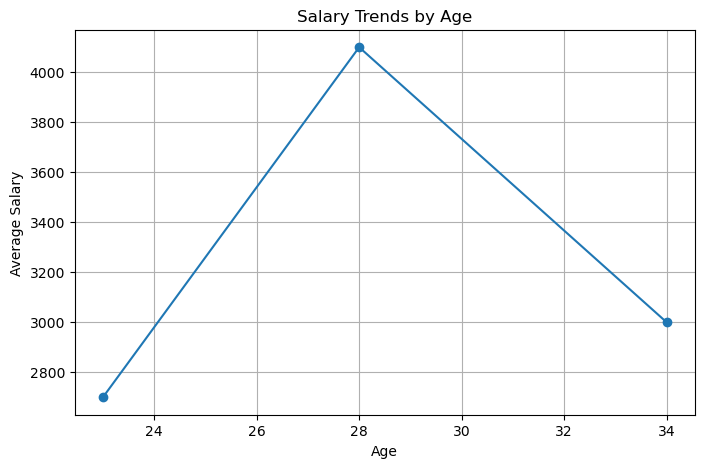

In [5]:
#tugas 7
import pandas as pd
import matplotlib.pyplot as plt

# 1) Ambil tren gaji rata-rata per usia lewat Spark SQL, lalu konversi ke pandas
salary_trends = spark.sql("""
SELECT Age,
       AVG(Salary) AS AverageSalary
FROM employees
GROUP BY Age
ORDER BY Age
""").toPandas()

display(salary_trends)  # opsional: lihat tabel kecilnya

# 2) Visualisasi tren (Age vs AverageSalary)
plt.figure(figsize=(8,5))
plt.plot(salary_trends["Age"], salary_trends["AverageSalary"], marker="o")
plt.xlabel("Age")
plt.ylabel("Average Salary")
plt.title("Salary Trends by Age")
plt.grid(True)
plt.show()